# 📘 AppleStore_EDA.ipynb



## 📌 Step 1: Import Required Libraries


In [1]:
#%pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

# Optional settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")



### 📌 Step 2: Load Cleaned CSV


In [3]:
import pandas as pd

# ✅ Use the new file name in the read_csv
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv")

# Check
print(df.head(1))


   sale_id  store_id  product_id  quantity  claim_id claim_date repair_status  \
0      201         1         101         5       NaN        NaN           NaN   

     product_name  category_id launch_date  price category_name  \
0  iPhone 13 Mini            1  14/09/2021    699   Smartphones   

          store_name       city country  revenue   sale_date  
0  Apple Store Saket  New Delhi   India     3495  2023-12-01  



#### 📌 Step 3: Revenue Column (if not already saved)


In [4]:
if 'revenue' not in df.columns:
    df['revenue'] = df['quantity'] * df['price']



#### 📌 Step 4: Total Revenue by Category


In [5]:
total_revenue_by_category = (
    df.groupby('category_name')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
print("\n💰 Total Revenue by Product Category:")
print(total_revenue_by_category)



💰 Total Revenue by Product Category:
  category_name  revenue
2       Laptops   257237
3   Smartphones   135427
4       Tablets   124977
0   Accessories    90720
1         Audio    10077
5     Wearables     7733



#### 📌 Step 5: Store with Highest Number of Sales


In [6]:
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 7 units sold



#### 📌 Step 6: Average Sale Value per Store


In [7]:
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
125  Apple Store Los Angeles  29995.0
72      Apple Store Fairview  17997.0
53     Apple Store Cleveland  13794.0
25        Apple Store Beirut   8094.0
141        Apple Store Miami   7794.0



#### 📌 Step 7: Top 5 Products by Quantity Sold


In [64]:
top_products = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products:")
print(top_products.head(10))



📦 Top 5 Best-Selling Products:
              product_name  quantity
110         iPhone 13 Mini        21
36             Mac Mini M2        18
70           iPad 10th Gen        14
82             iPad Aurora        14
6            AirPods Pro 2        14
114          iPhone 14 Pro        13
126             iPhone Air        12
21   Apple Watch HermÃÂ¨s        12
0                AirPods 3        12
31      Apple Watch Summit        11


### 📊 Sales Analysis

In [9]:
#1. What is the total revenue generated across all stores?
total_revenue = df['revenue'].sum()
print(f"\n💵 Total Revenue Generated: ${total_revenue:,.2f}")



💵 Total Revenue Generated: $626,171.00


In [10]:
#2. Which product generated the highest revenue?
highest_revenue_product = df.groupby('product_name')['revenue'].sum().idxmax()
highest_revenue = df.groupby('product_name')['revenue'].sum().max() 
print(f"\n💰 Product with Highest Revenue: {highest_revenue_product} (${highest_revenue:,.2f})")



💰 Product with Highest Revenue: Mac Pro (2019) ($53,991.00)


In [11]:
#3. What is the total revenue by product category?
total_revenue_by_category = df.groupby('category_name')['revenue'].sum().reset_index()
total_revenue_by_category = total_revenue_by_category.sort_values(by='revenue', ascending=False)
print("\n📊 Total Revenue by Product Category:")
print(total_revenue_by_category.head()) 



📊 Total Revenue by Product Category:
  category_name  revenue
2       Laptops   257237
3   Smartphones   135427
4       Tablets   124977
0   Accessories    90720
1         Audio    10077


In [12]:
#4. Which store has the highest number of sales?
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 7 units sold


In [13]:
# 5. Which city has the highest total revenue?
city_revenue = df.groupby('city')['revenue'].sum().reset_index()
city_revenue = city_revenue.sort_values(by='revenue', ascending=False)
print("\n🌆 City with Highest Total Revenue:")
print(f"{city_revenue.iloc[0]['city']} → ${city_revenue.iloc[0]['revenue']:,.2f}")



🌆 City with Highest Total Revenue:
Los Angeles → $29,995.00


In [14]:
# 6. What is the average sale value per store?
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
125  Apple Store Los Angeles  29995.0
72      Apple Store Fairview  17997.0
53     Apple Store Cleveland  13794.0
25        Apple Store Beirut   8094.0
141        Apple Store Miami   7794.0


### 📦 Product Performance

In [15]:
#1. What are the top 5 best-selling products by quantity?
top_products_by_quantity = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products by Quantity:")
print(top_products_by_quantity.head())



📦 Top 5 Best-Selling Products by Quantity:
       product_name  quantity
110  iPhone 13 Mini        21
36      Mac Mini M2        18
70    iPad 10th Gen        14
82      iPad Aurora        14
6     AirPods Pro 2        14


In [16]:
# 2. What are the top 5 most returned/repaired products (from warranty/claim data)?
top_returned_products = (
    df[df['claim_id'].notnull()]
    .groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n🔧 Top 5 Most Returned/Repair Products:")
print(top_returned_products.head())



🔧 Top 5 Most Returned/Repair Products:
                 product_name  quantity
58             iPhone 13 Mini        13
10      Apple Watch HermÃÂ¨s         9
45               iPad Explore         8
60              iPhone 14 Pro         8
15  Apple Watch Titan Edition         7


In [17]:
# 3. What is the average price of products by category?
avg_price_by_category = (
    df.groupby('category_name')['price']
    .mean()
    .reset_index()
    .round(2)
    .sort_values(by='price', ascending=False)
)
print("\n💲 Average Price of Products by Category:")
print(avg_price_by_category.head())



💲 Average Price of Products by Category:
  category_name    price
2       Laptops  1622.21
3   Smartphones   882.57
4       Tablets   639.91
0   Accessories   584.56
5     Wearables   442.75


In [18]:
# 4. Which product category has the most diverse price range?
price_range_by_category = (
    df.groupby('category_name')['price']
    .agg(['min', 'max'])
    .reset_index()
)
print("\n📊 Price Range by Product Category:")
print(price_range_by_category.head())



📊 Price Range by Product Category:
  category_name  min   max
0   Accessories   59  1349
1         Audio  179   549
2       Laptops  699  5999
3   Smartphones  429  1499
4       Tablets  329  1299


### 🏬 Store Insights

In [19]:
# 1. What is the number of stores per country?
stores_per_country = df['country'].value_counts().reset_index()
stores_per_country.columns = ['country', 'number_of_stores']
print("\n🌍 Number of Stores per Country:")
print(stores_per_country.head())



🌍 Number of Stores per Country:
          country  number_of_stores
0   United States               104
1           Japan                13
2          France                10
3  United Kingdom                 7
4           India                 7


In [20]:
# 2. Which country generates the most revenue?
country_revenue = df.groupby('country')['revenue'].sum().reset_index()
country_revenue = country_revenue.sort_values(by='revenue', ascending=False)
print("\n🌍 Country with Highest Revenue:")
print(f"{country_revenue.iloc[0]['country']} → ${country_revenue.iloc[0]['revenue']:,.2f}")



🌍 Country with Highest Revenue:
United States → $312,777.00


In [21]:
df = pd.read_csv("cleaned_apple_store_data.csv")

# Parse the sale_date column properly
df['sale_date'] = pd.to_datetime(df['sale_date'], dayfirst=True, errors='coerce')


In [22]:

# Convert sale_date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])


In [23]:

# 🗓️ Create Year-Month column
df['year_month'] = df['sale_date'].dt.to_period('M')


In [24]:
print(df['sale_date'].head())  # First 5 dates
print(df['sale_date'].isna().sum())  # Check for invalid rows (should be 0 ideally)


0   2023-01-12
1          NaT
2   2024-05-05
3          NaT
4          NaT
Name: sale_date, dtype: datetime64[ns]
210


In [25]:

# 📈 Group by Year-Month and sum revenue
df['revenue'] = df['quantity'] * df['price']
monthly_sales = df.groupby('year_month')['revenue'].sum().reset_index()


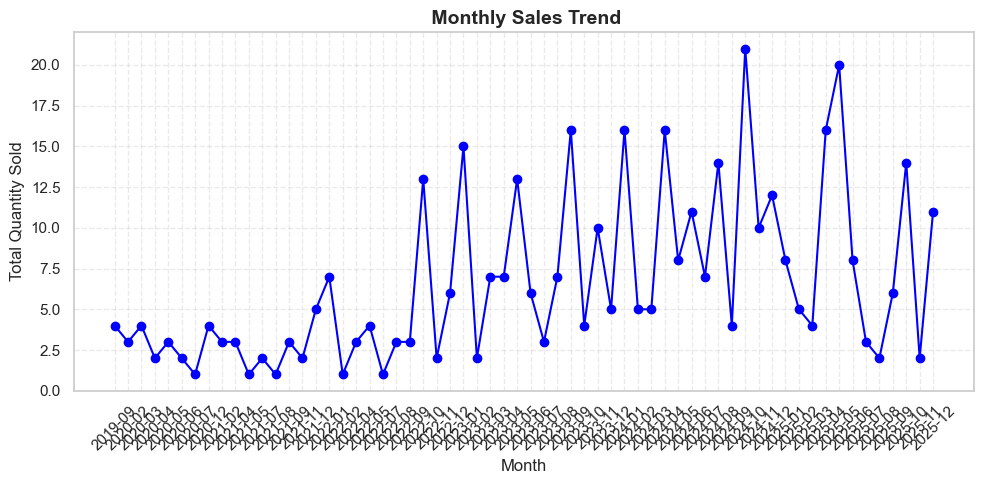

In [26]:

df['year_month'] = df['sale_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['quantity'], marker='o', color='blue')
plt.title(" Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


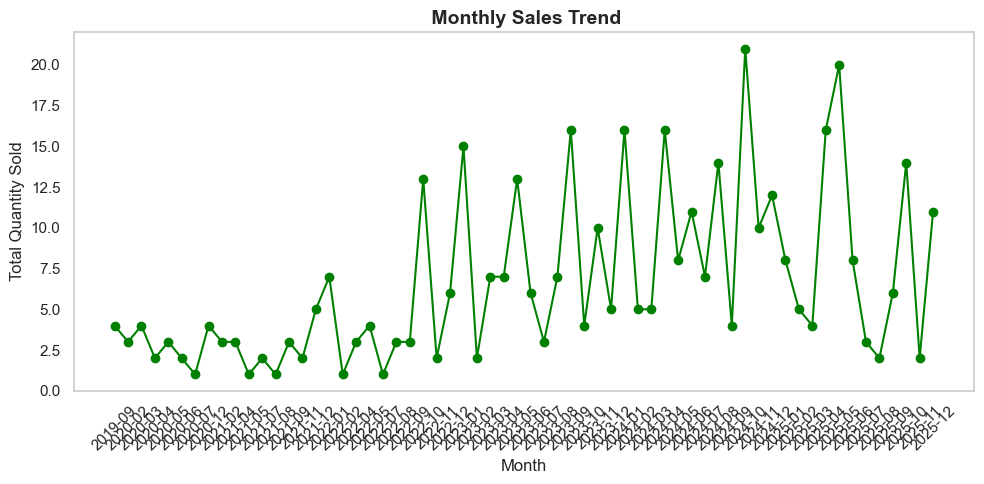

In [27]:
df['year_month'] = df['sale_date'].dt.to_period('M')  # Monthly group
df['year'] = df['sale_date'].dt.year  # Yearly group

monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['quantity'], marker='o', color='green')
plt.title(" Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle='', alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
#4. Which store has the highest average sale amount per transaction?
# Make sure revenue column exists
if 'revenue' not in df.columns:
    df['revenue'] = df['quantity'] * df['price']

# Group by store and compute average revenue per transaction
avg_sale_per_transaction = (
    df.groupby('store_name')
      .agg(total_revenue=('revenue', 'sum'),
           total_sales=('sale_id', 'nunique'))
)

avg_sale_per_transaction['avg_sale_per_transaction'] = (
    avg_sale_per_transaction['total_revenue'] / avg_sale_per_transaction['total_sales']
)

# Sort to get highest
avg_sale_per_transaction = avg_sale_per_transaction.sort_values(
    by='avg_sale_per_transaction', ascending=False
)

# Display top store
print("\n🏪 Store with Highest Average Sale Amount per Transaction:")
print(avg_sale_per_transaction[['avg_sale_per_transaction']].head(1))



🏪 Store with Highest Average Sale Amount per Transaction:
                         avg_sale_per_transaction
store_name                                       
Apple Store Los Angeles                   15326.5


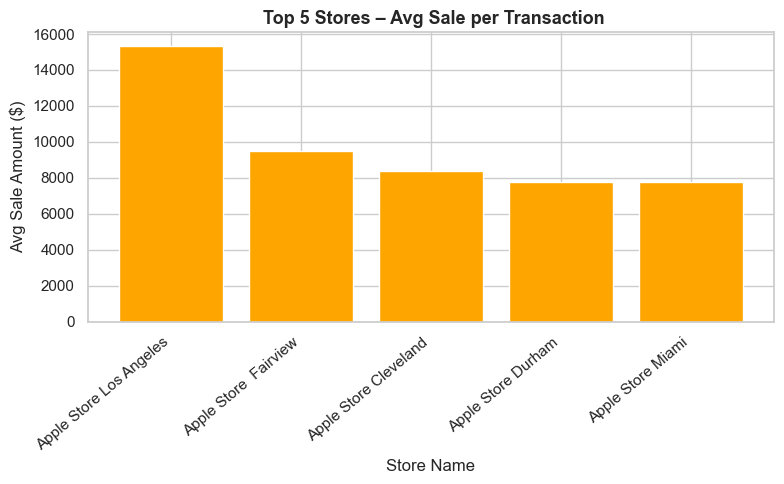

In [29]:
import matplotlib.pyplot as plt

# 🔝 Limit to Top 5 Stores Only
top5_avg = avg_sale_per_transaction.head(5)

# 📊 Clean Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(top5_avg.index, top5_avg['avg_sale_per_transaction'], color='orange')

plt.title(' Top 5 Stores – Avg Sale per Transaction', fontsize=13, weight='bold')
plt.xlabel('Store Name')
plt.ylabel('Avg Sale Amount ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
# Grid line removed

plt.show()



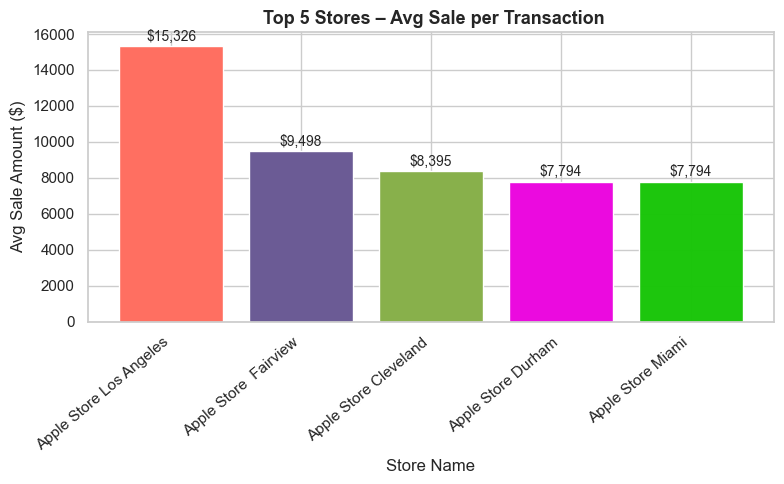

In [30]:
import matplotlib.pyplot as plt

# 🎨 Custom colors (you can change or add more)
colors = ['#FF6F61', '#6B5B95', '#88B04B',  "#EB0ADF","#18c508fa"]

# 🔝 Plot top 5 with different colors
plt.figure(figsize=(8, 5))
plt.bar(top5_avg.index, top5_avg['avg_sale_per_transaction'], color=colors)

plt.title(' Top 5 Stores – Avg Sale per Transaction', fontsize=13, weight='bold')
plt.xlabel('Store Name')
plt.ylabel('Avg Sale Amount ($)')
plt.xticks(rotation=40, ha='right')
for i, val in enumerate(top5_avg['avg_sale_per_transaction']):
    plt.text(i, val + 300, f"${val:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
# Grid line removed

plt.show()


### 🛠️ Warranty Analysis

In [31]:
# 1. What percentage of sales result in warranty claims?
# Count total sales and sales with claims
total_sales = df['sale_id'].nunique()
sales_with_claims = df[df['claim_id'].notna()]['sale_id'].nunique()

claim_percentage = (sales_with_claims / total_sales) * 100
print(f"🔧 Warranty Claim Rate: {claim_percentage:.2f}%")


🔧 Warranty Claim Rate: 34.83%


In [32]:
# 2. Which product has the highest claim rate?
# Count claims and total sales per product
product_claims = df[df['claim_id'].notna()].groupby('product_name')['sale_id'].nunique()
product_sales = df.groupby('product_name')['sale_id'].nunique()

claim_rate = (product_claims / product_sales * 100).fillna(0)
top_claimed_product = claim_rate.sort_values(ascending=False).head(1)

print("\n🚨 Product with Highest Claim Rate:")
print(top_claimed_product)



🚨 Product with Highest Claim Rate:
product_name
AirPods 3rd Gen    100.0
Name: sale_id, dtype: float64



🛠️ Repair Status Distribution:
repair_status
Paid Repaired    33
In Progress      25
Warranty Void    21
Rejected         21
Repaired         11
Replaced          8
In Process        5
Name: count, dtype: int64


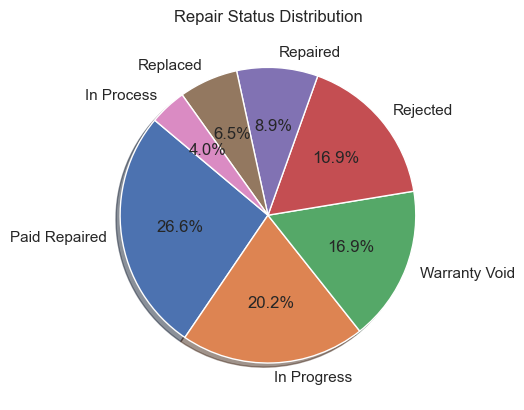

In [33]:
#  3. What is the distribution of repair statuses?
repair_dist = df['repair_status'].value_counts(dropna=True)

print("\n🛠️ Repair Status Distribution:")
print(repair_dist)

#Optional 📊 Pie Chart:


import matplotlib.pyplot as plt

repair_dist.plot(kind='pie', autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Repair Status Distribution")
plt.ylabel('')
plt.show()



🏬 Stores with Most Warranty Claims:
store_name
Apple Store Baltimore    3
Apple Store Milwaukee    3
Apple Store Kyoto        3
Apple Store Zagreb       3
Apple Store Cleveland    2
Name: claim_id, dtype: int64


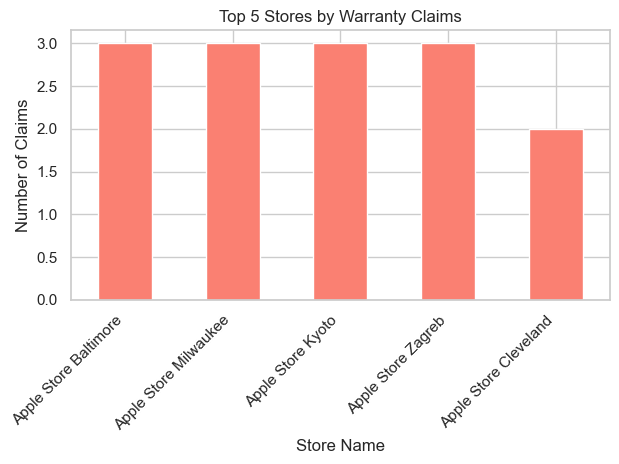

In [34]:
# 4. Are certain stores seeing more warranty claims than others?
claims_by_store = (
    df[df['claim_id'].notna()]
    .groupby('store_name')['claim_id']
    .count()
    .sort_values(ascending=False)
)

print("\n🏬 Stores with Most Warranty Claims:")
print(claims_by_store.head(5))

claims_by_store.head(5).plot(kind='bar', color='salmon')
plt.title("Top 5 Stores by Warranty Claims")
plt.xlabel("Store Name")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 🔍 Deep Dives / Optional

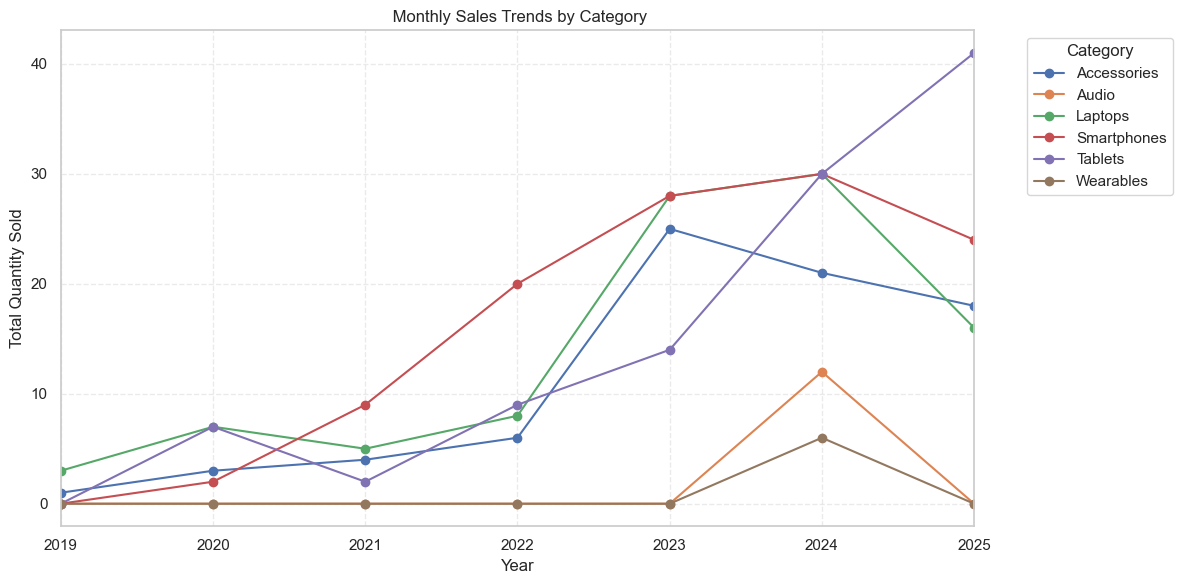

In [35]:
# 1. Which categories show seasonal trends in sales?
# 🔄 Convert sale_date to datetime (if not done yet)
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

# 📅 Create 'Month' column
df['month'] = df['sale_date'].dt.to_period('Y')

# 📊 Monthly sales quantity by category
monthly_category_sales = (
    df.groupby(['month', 'category_name'])['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

# ✅ Plot
monthly_category_sales.plot(figsize=(12, 6), marker='o')
plt.title(" Monthly Sales Trends by Category")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



 Sales Performance Based on Launch Year:
launched_after_2022
Before or In 2022    420
After 2022           548
Name: quantity, dtype: int64


C:\Users\Syed\AppData\Local\Temp\ipykernel_9400\2622975094.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['launch_date'] = pd.to_datetime(df['launch_date'], errors='coerce')


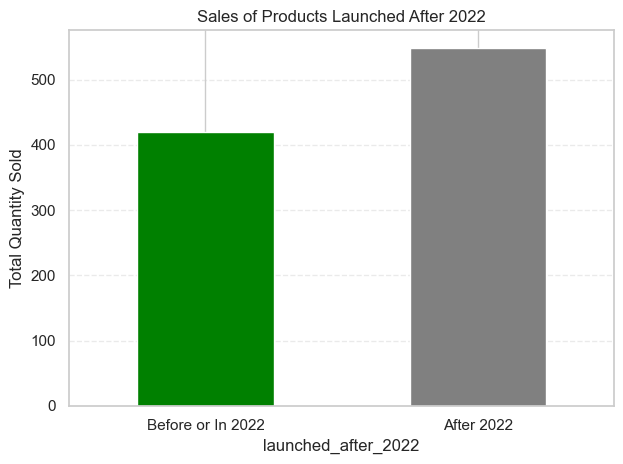

In [36]:
#  2. Are products launched after 2022 performing better in sales?
# 📅 Convert launch_date to datetime
df['launch_date'] = pd.to_datetime(df['launch_date'], errors='coerce')

# 📌 Add flag column
df['launched_after_2022'] = df['launch_date'].dt.year > 2022

# 📊 Group and compare total sales quantity
launch_performance = (
    df.groupby('launched_after_2022')['quantity']
    .sum()
    .rename({True: 'After 2022', False: 'Before or In 2022'})
)

# ✅ Print and visualize
print("\n Sales Performance Based on Launch Year:")
print(launch_performance)

launch_performance.plot(kind='bar', color=['green', 'gray'])
plt.title("Sales of Products Launched After 2022")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [37]:
num_stores_ny = df[df['city'] == 'Dubai']['store_name'].nunique()
print(f"\n🏙️ Number of Stores in City Dubai: {num_stores_ny}")




🏙️ Number of Stores in City Dubai: 2


In [38]:
city = "Abu Dhabi"
num_stores = df[df['city'] == city]['store_name'].nunique()

print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")




🏙️ Number of Stores in City Abu Dhabi: 2


In [39]:
city = "Delhi"

# Filter stores in that city
stores_in_city = df[df['city'] == city]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_city.nunique()

# Print
print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")
print(f"🏬 Store(s) in {city}:")
for store in stores_in_city:
    print(f"• {store}")



🏙️ Number of Stores in City Delhi: 2
🏬 Store(s) in Delhi:
• Apple Store Saket Mall
• Apple Store Rajouri Garden


In [40]:
city = "New York"

# Filter stores in that city
stores_in_city = df[df['city'] == city]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_city.nunique()

# Print
print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")
print(f"🏬 Store(s) in {city}:")
for store in stores_in_city:
    print(f"• {store}")



🏙️ Number of Stores in City New York: 2
🏬 Store(s) in New York:
• Apple Store New York
• Apple Store Ridge Hill


In [41]:
city = "New York"

# Filter stores in that city
stores_in_city = df[df['city'] == city]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_city.nunique()

# Print
print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")
print(f"🏬 Store(s) in {city}:")
for store in stores_in_city:
    print(f"• {store}")



🏙️ Number of Stores in City New York: 2
🏬 Store(s) in New York:
• Apple Store New York
• Apple Store Ridge Hill


In [42]:
country= "Pakistan"

# Filter stores in that city
stores_in_country = df[df['country'] == country]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_country.nunique()

# Print
print(f"\n🏙️ Number of Stores in country {country}: {num_stores}")
print(f"🏬 Store(s) in {country}:")
for store in stores_in_country:
    print(f"• {store}")



🏙️ Number of Stores in country Pakistan: 1
🏬 Store(s) in Pakistan:
• Apple Store Islamabad


In [43]:
country = "India"

# Filter stores in that country
stores_in_country = df[df['country'] == country][['store_name', 'city']].drop_duplicates()

# Count number of unique store names
num_stores = stores_in_country['store_name'].nunique()

# Print result
print(f"\n🏙️ Number of Stores in country {country}: {num_stores}")
print(f"🏬 Store(s) in {country}:")

# Show each store with its city
for index, row in stores_in_country.iterrows():
    print(f"• {row['store_name']} (📍{row['city']})")



🏙️ Number of Stores in country India: 7
🏬 Store(s) in India:
• Apple Store Saket (📍New Delhi)
• Apple Store BKC (📍Mumbai)
• Apple Store Brigade Road (📍Bangalore)
• Apple Store Camp (📍Pune)
• Apple Store Saket Mall (📍Delhi)
• Apple Store Rajouri Garden (📍Delhi)
• Apple Store Phoenix Marketcity (📍Mumbai)


In [44]:
df.head()


,sale_id,store_id,product_id,quantity,claim_id,claim_date,repair_status,product_name,category_id,launch_date,price,category_name,store_name,city,country,revenue,sale_date,year_month,year,month,launched_after_2022
0,201,1,101,5,NaN,NaN,NaN,iPhone 13 Mini,1,2021-09-14,699,Smartphones,Apple Store Saket,New Delhi,India,3495,2023-01-12,2023-01,2023.0,2023,False
1,202,2,102,2,NaN,NaN,NaN,"MacBook Pro M1 13""",2,2021-10-18,1299,Laptops,Apple Store London,London,UK,2598,NaT,NaT,NaN,NaT,False
2,203,3,103,1,NaN,NaN,NaN,iPad Mini 6,3,2021-09-24,499,Tablets,Apple Store Yas Mall,Abu Dhabi,UAE,499,2024-05-05,2024-05,2024.0,2024,False
3,204,4,104,3,NaN,NaN,NaN,Apple Watch Series 7,4,2021-10-15,399,Accessories,Apple Store Tokyo,Tokyo,Japan,1197,NaT,NaT,NaN,NaT,False
4,205,2,101,2,301.0,10/01/2021,Paid Repaired,iPhone 13 Mini,1,2021-09-14,699,Smartphones,Apple Store London,London,UK,1398,NaT,NaT,NaN,NaT,False


In [45]:
import pandas as pd

# Load your CSV
df = pd.read_csv("cleaned_store_data_final.csv")

# Find duplicate store names (regardless of city)
duplicate_names = df[df.duplicated(subset=['store_name'], keep=False)]

# Show all duplicates
print("🔁 Duplicate Store Names Detected:")
print(duplicate_names[['store_name', 'city']].sort_values('store_name'))



🔁 Duplicate Store Names Detected:
Empty DataFrame
Columns: [store_name, city]
Index: []


In [ ]:
import pandas as pd

# Load original file
df = pd.read_csv("cleaned_store_data.csv")

# Step 1: Normalize text: strip, lowercase, remove extra spaces
df['store_name'] = df['store_name'].astype(str).str.strip()
df['store_name'] = df['store_name'].str.replace(r'\s+', ' ', regex=True)  # fix double/triple spaces
df['store_name'] = df['store_name'].str.replace(r'(?<=[a-z])(?=[A-Z])', ' ', regex=True)  # Add space between camelCase
df['store_name'] = df['store_name'].str.title()  # Capitalize nicely

df['city'] = df['city'].astype(str).str.strip().str.title()  # Fix city like 'delhi' vs 'Delhi'

# Step 2: Remove exact duplicates (store_name + city)
df_cleaned = df.drop_duplicates(subset=['store_name', 'city'])

# Step 3: Check if any store_name appears more than once (even in different cities)
dups = df_cleaned[df_cleaned.duplicated(subset='store_name', keep=False)]

print("\n🔁 Remaining Duplicate Store Names (across cities or due to hidden typos):")
print(dups[['store_name', 'city']].sort_values('store_name'))

# Step 4: Save cleaned file
df_cleaned.to_csv("final_store_data_normalized.csv", index=False)
print("\n✅ Fully cleaned file saved as 'final_store_data_normalized.csv'")



🔁 Remaining Duplicate Store Names (across cities or due to hidden typos):
Empty DataFrame
Columns: [store_name, city]
Index: []

✅ Fully cleaned file saved as 'cleaned_store_data_final.csv'


In [56]:
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv")


In [57]:
import pandas as pd

# Step 1: Load final CSV (ensure correct path)
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv")

# Step 2: Show exact duplicates based on store_name + city
exact_dups = df[df.duplicated(subset=['store_name', 'city'], keep=False)]

print(f"\n🔁 Exact Duplicates (store_name + city): {len(exact_dups)}")
print(exact_dups[['store_name', 'city']].sort_values('store_name'))



🔁 Exact Duplicates (store_name + city): 0
Empty DataFrame
Columns: [store_name, city]
Index: []


In [58]:
# Step 3: Duplicate store_name used in more than one city
multi_city_dups = df[df.duplicated(subset=['store_name'], keep=False)]

print(f"\n🏙️ Store Names Appearing in Multiple Cities: {len(multi_city_dups)}")
print(multi_city_dups[['store_name', 'city']].sort_values('store_name'))



🏙️ Store Names Appearing in Multiple Cities: 0
Empty DataFrame
Columns: [store_name, city]
Index: []


In [59]:
# Step 4: See unique characters used in store names
unique_names = df['store_name'].unique()

for name in unique_names:
    print(f"{repr(name)} → length: {len(name)}")


'Apple Store Saket' → length: 17
'Apple Store London' → length: 18
'Apple Store Yas Mall' → length: 20
'Apple Store Tokyo' → length: 17
'Apple Store Sydney' → length: 18
'Apple Store Vienna' → length: 18
'Apple Store Sã\x83Â£O Paulo' → length: 24
'Apple Store Jakarta' → length: 19
'Apple Store Zagreb' → length: 18
'Apple Store Canberra' → length: 20
'Apple Store Berlin' → length: 18
'Apple Store Kampala' → length: 19
'Apple Store Lexington' → length: 21
'Apple Store Seoul' → length: 17
'Apple Store Chandler' → length: 20
'Apple Store Yorkdale' → length: 20
'Apple Store San Juan' → length: 20
'Apple Store Kansas City' → length: 23
'Apple Store Sacramento' → length: 22
'Apple Store Islamabad' → length: 21
'Apple Store Memphis' → length: 19
'Apple Store Istanbul' → length: 20
'Apple Store Buffalo East' → length: 24
'Apple Store Kingston' → length: 20
'Apple Store Athens' → length: 18
'Apple Store Temecula' → length: 20
'Apple Store Casablanca' → length: 22
'Apple Store Manama' → length: 1

In [60]:
import unicodedata

# Normalize store names to proper Unicode
df['store_name'] = df['store_name'].apply(lambda x: unicodedata.normalize("NFKC", x))


In [61]:
df.to_csv("final_store_data_normalized.csv", index=False)


In [69]:
df.head(13)


,sale_id,store_id,product_id,quantity,claim_id,claim_date,repair_status,product_name,category_id,launch_date,price,category_name,store_name,city,country,revenue,sale_date
0,201,1,101,5,NaN,NaN,NaN,iPhone 13 Mini,1,14/09/2021,699,Smartphones,Apple Store Saket,New Delhi,India,3495,2023-12-01
1,202,2,102,2,NaN,NaN,NaN,"MacBook Pro M1 13""",2,18/10/2021,1299,Laptops,Apple Store London,London,UK,2598,2023-12-20
2,203,3,103,1,NaN,NaN,NaN,iPad Mini 6,3,24/09/2021,499,Tablets,Apple Store Yas Mall,Abu Dhabi,UAE,499,2024-05-05
3,204,4,104,3,NaN,NaN,NaN,Apple Watch Series 7,4,15/10/2021,399,Accessories,Apple Store Tokyo,Tokyo,Japan,1197,2023-12-15
4,206,5,105,4,303.0,NaN,Paid Repaired,iPhone 14 Pro,1,16/09/2022,999,Smartphones,Apple Store Sydney,Sydney,Australia,3996,2022-10-10
5,210,21,120,2,306.0,05/08/2023,Paid Repaired,"MacBook Pro M2 14""",2,17/01/2023,1999,Laptops,Apple Store Vienna,Vienna,Austria,3998,2024-03-01
6,211,14,189,1,307.0,NaN,In Progress,iPad Air 2,3,22/10/2014,399,Tablets,Apple Store SãÂ£O Paulo,SãÂ£O Paulo,Brazil,399,2023-12-15
7,212,65,213,4,NaN,NaN,NaN,"iPad 10.9""",3,17/10/2023,449,Tablets,Apple Store Jakarta,Jakarta,Indonesia,1796,2022-06-10
8,213,88,277,3,308.0,NaN,Paid Repaired,iPad Explore,3,08/11/2025,749,Tablets,Apple Store Zagreb,Zagreb,Croatia,2247,2025-01-05
9,214,100,141,2,NaN,NaN,NaN,iPad Mini 5,3,18/03/2019,399,Tablets,Apple Store Canberra,Canberra,Australia,798,2021-11-20


In [ ]:
total_sales = df['price'] * df['quantity']
print(total_sales)


0      3495
1      2598
2       499
3      1197
4      3996
       ... 
235    1998
236    2796
237     498
238    1287
239     895
Length: 240, dtype: int64


In [72]:
import pandas as pd

# Load CSV
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv")

# Fix corrupted name manually
df['product_name'] = df['product_name'].replace('Apple Watch HermÃÂ¨s', 'Apple Watch Hermès')

# Optional: normalize entire column to clean similar issues
import unicodedata
df['product_name'] = df['product_name'].apply(lambda x: unicodedata.normalize("NFKC", str(x)).strip())

# Save cleaned version
df.to_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv", index=False)

print("✅ Product name fixed and file saved.")


✅ Product name fixed and file saved.


In [ ]:
# Show all unique product names
print(df['product_name'].unique())


['iPhone 13 Mini' 'MacBook Pro M1 13"' 'iPad Mini 6'
 'Apple Watch Series 7' 'iPhone 14 Pro' 'MacBook Pro M2 14"' 'iPad Air 2'
 'iPad 10.9"' 'iPad Explore' 'iPad Mini 5' 'Magic Trackpad 2'
 'iPad Studio' 'iPad Touch Pro' 'MacBook SE' 'AirPods 3rd Gen'
 'AirPods Pro' 'iPhone Spark' 'Apple Watch Series 6' 'iPhone 7'
 'Mac Mini M2' 'Apple Pencil 2' 'iPhone 15 SE' 'MacBook NotePad M3'
 'MacBook Air M1' 'iPad Aurora' 'iPad Pro M2 12.9"' 'iPad Air M2'
 'MacBook Air Intel' 'AirPods Studio' 'MacBook Pro 17"' 'Mac Pro (2019)'
 'iPad Solar' 'Apple AirTag (4 Pack)' 'iPad 5th Gen' 'MacBook Air M2'
 'Apple Watch Hermès' 'iPad 10th Gen' 'Apple Watch Explorer Edition'
 'MacBook Air 11"' 'iPad 8th Gen' 'iPad 11th Gen' 'iPad Lite'
 'iPad Pro 11"' 'MacBook Air M2 Classic' 'Apple Watch Summit'
 'iPad Classic (2025)' 'MacBook Go' 'iPhone 12 Mini'
 'MacBook Studio Display' 'Apple Watch Aura' 'Apple Watch Max Steel'
 'AirPods Pro 2' 'Apple Watch SE 3' 'MacBook Air SE 13"' 'iPhone 7 Plus'
 'iPad Pro M1' 'iPh

In [76]:
import unicodedata

def normalize_unicode(text):
    return unicodedata.normalize("NFKC", str(text)).strip()

df['store_name'] = df['store_name'].apply(normalize_unicode)
df['city'] = df['city'].apply(normalize_unicode)


In [77]:
df.to_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\final_store_data_normalized.csv", index=False)
print("✅ Saved cleaned data.")


✅ Saved cleaned data.


In [ ]:
df.head(13)


,sale_id,store_id,product_id,quantity,claim_id,claim_date,repair_status,product_name,category_id,launch_date,price,category_name,store_name,city,country,revenue,sale_date
0,201,1,101,5,NaN,NaN,NaN,iPhone 13 Mini,1,14/09/2021,699,Smartphones,Apple Store Saket,New Delhi,India,3495,2023-12-01
1,202,2,102,2,NaN,NaN,NaN,"MacBook Pro M1 13""",2,18/10/2021,1299,Laptops,Apple Store London,London,UK,2598,2023-12-20
2,203,3,103,1,NaN,NaN,NaN,iPad Mini 6,3,24/09/2021,499,Tablets,Apple Store Yas Mall,Abu Dhabi,UAE,499,2024-05-05
3,204,4,104,3,NaN,NaN,NaN,Apple Watch Series 7,4,15/10/2021,399,Accessories,Apple Store Tokyo,Tokyo,Japan,1197,2023-12-15
4,206,5,105,4,303.0,NaN,Paid Repaired,iPhone 14 Pro,1,16/09/2022,999,Smartphones,Apple Store Sydney,Sydney,Australia,3996,2022-10-10
5,210,21,120,2,306.0,05/08/2023,Paid Repaired,"MacBook Pro M2 14""",2,17/01/2023,1999,Laptops,Apple Store Vienna,Vienna,Austria,3998,2024-03-01
6,211,14,189,1,307.0,NaN,In Progress,iPad Air 2,3,22/10/2014,399,Tablets,Apple Store SãÂ£O Paulo,SãÂ£O Paulo,Brazil,399,2023-12-15
7,212,65,213,4,NaN,NaN,NaN,"iPad 10.9""",3,17/10/2023,449,Tablets,Apple Store Jakarta,Jakarta,Indonesia,1796,2022-06-10
8,213,88,277,3,308.0,NaN,Paid Repaired,iPad Explore,3,08/11/2025,749,Tablets,Apple Store Zagreb,Zagreb,Croatia,2247,2025-01-05
9,214,100,141,2,NaN,NaN,NaN,iPad Mini 5,3,18/03/2019,399,Tablets,Apple Store Canberra,Canberra,Australia,798,2021-11-20


####  Setup for Date Format and Missing Date in Sales_date

#### Replace store name
df['store_name'] = df['store_name'].replace({
    'Apple Store Dubai': 'Apple Store Yas Mall'
})
##### Replace city for that store
df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'

df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'
df.loc[df['store_name'] == 'Apple Store Ridge Hill', ['store_name', 'city']] = ['Apple Store Ridge Hill', 'New York']
